In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

native_df = pd.read_csv('output_files/native/native.csv')
decoys_df = pd.read_csv('output_files/decoys/decoys.csv')
all_native_df = pd.read_csv('output_files/native/all_native.csv')

N_RINGS = 10
RDF_DETECTOR_PREFIXES = ('physical_ring', 'zernike_ring', 'roughness_ring')
RDF_COL_PATTERNS = (
    'physical_ring{rid}_mean',
    'physical_ring{rid}_uncertainty',
    'zernike_ring{rid}_mean',
    'zernike_ring{rid}_uncertainty',
    'roughness_ring{rid}',
)


def _build_ring_columns(df, patterns, n_rings=N_RINGS):
    ring_cols = {}
    for rid in range(1, n_rings + 1):
        cols = []
        for pattern in patterns:
            col = pattern.format(rid=rid)
            if col in df.columns:
                cols.append(col)
        ring_cols[rid] = cols
    return ring_cols


def _ring_has_value(row, cols):
    if not cols:
        return False
    vals = pd.to_numeric(row[cols], errors='coerce').to_numpy(dtype=float)
    return np.isfinite(vals).any()


def truncate_rdf_and_adjust_radius(df, radius_col='radius', n_rings=N_RINGS):
    df = df.copy()
    if radius_col not in df.columns:
        raise ValueError(f"Missing '{radius_col}' column")

    detector_patterns = tuple(f'{prefix}' + '{rid}_mean' if prefix != 'roughness_ring' else f'{prefix}' + '{rid}' for prefix in RDF_DETECTOR_PREFIXES)
    detector_cols = _build_ring_columns(df, detector_patterns, n_rings=n_rings)
    rdf_cols = _build_ring_columns(df, RDF_COL_PATTERNS, n_rings=n_rings)

    new_radius = pd.to_numeric(df[radius_col], errors='coerce').copy()

    for idx in df.index:
        row = df.loc[idx]
        has_values = {rid: _ring_has_value(row, detector_cols[rid]) for rid in range(1, n_rings + 1)}

        first_valid = next((rid for rid in range(1, n_rings + 1) if has_values[rid]), None)
        if first_valid is None:
            for rid in range(1, n_rings + 1):
                for col in rdf_cols[rid]:
                    df.at[idx, col] = np.nan
                ring_col = f'ring{rid}_mean_A'
                if ring_col in df.columns:
                    df.at[idx, ring_col] = np.nan
            new_radius.at[idx] = np.nan
            continue

        last_valid = first_valid
        for rid in range(first_valid + 1, n_rings + 1):
            if has_values[rid]:
                last_valid = rid
            else:
                break

        for rid in range(1, n_rings + 1):
            keep_ring = first_valid <= rid <= last_valid
            if not keep_ring:
                for col in rdf_cols[rid]:
                    df.at[idx, col] = np.nan

        original_radius = pd.to_numeric(pd.Series([row[radius_col]]), errors='coerce').iloc[0]
        if np.isfinite(original_radius) and original_radius > 0:
            new_radius.at[idx] = float(original_radius) * float(last_valid) / float(n_rings)
        else:
            new_radius.at[idx] = np.nan

        for rid in range(1, n_rings + 1):
            ring_col = f'ring{rid}_mean_A'
            if ring_col not in df.columns:
                continue
            keep_ring = first_valid <= rid <= last_valid
            if keep_ring and np.isfinite(original_radius) and original_radius > 0:
                df.at[idx, ring_col] = float(original_radius) * (rid - 0.5) / float(n_rings)
            else:
                df.at[idx, ring_col] = np.nan

    df[radius_col] = new_radius
    return df


def build_binned_real_rdf_profile(subset_df, metric_cols, radius_col='radius', bin_width=2.0, max_x=50.0):
    bin_edges = np.arange(0.0, max_x + bin_width, bin_width)
    bin_ids = list(range(len(bin_edges) - 1))
    per_bin_values = {bid: [] for bid in bin_ids}

    for _, row in subset_df.iterrows():
        radius_value = pd.to_numeric(pd.Series([row[radius_col]]), errors='coerce').iloc[0]
        if not np.isfinite(radius_value) or radius_value <= 0:
            continue

        for rid, metric_col in enumerate(metric_cols, start=1):
            if metric_col not in subset_df.columns:
                continue
            value = pd.to_numeric(pd.Series([row[metric_col]]), errors='coerce').iloc[0]
            if not np.isfinite(value):
                continue
            x_position = (rid - 0.5) * float(radius_value) / float(N_RINGS)
            if not np.isfinite(x_position) or x_position > max_x:
                continue
            bin_index = int(np.floor(x_position / bin_width))
            bin_index = min(bin_index, len(bin_ids) - 1)
            per_bin_values[bin_index].append(float(value))

    bin_centers = bin_edges[:-1] + bin_width / 2.0
    x_values = []
    y_values = []
    for bid, center in zip(bin_ids, bin_centers):
        values = per_bin_values[bid]
        if not values:
            continue
        x_values.append(float(center))
        y_values.append(float(np.mean(values)))

    return np.asarray(x_values, dtype=float), np.asarray(y_values, dtype=float)


def add_ring_mean_columns(df, radius_col='radius', n_rings=N_RINGS):
    for ring_id in range(1, n_rings + 1):
        df[f'ring{ring_id}_mean_A'] = pd.to_numeric(df[radius_col], errors='coerce') * (ring_id - 0.5) / n_rings
    return df


native_df = add_ring_mean_columns(native_df)
decoys_df = add_ring_mean_columns(decoys_df)
all_native_df = add_ring_mean_columns(all_native_df)

#native_df = truncate_rdf_and_adjust_radius(native_df)
#decoys_df = truncate_rdf_and_adjust_radius(decoys_df)
#all_native_df = truncate_rdf_and_adjust_radius(all_native_df)

native_labeled = native_df.copy()
native_labeled['dataset_label'] = 'native'

decoys_labeled = decoys_df.copy()
decoys_labeled['complex_name'] = decoys_labeled['complex_name'].astype(str).str.split('-').str[0].str[:4]
decoys_labeled['dataset_label'] = 'decoy'

tot_df = pd.concat([native_labeled, decoys_labeled], ignore_index=True)

rings = [f'ring{n}_mean_A' for n in range(1, 11)]
zernike = [f'zernike_ring{n}_mean' for n in range(1, 11)]
zernike_sigma = [f'zernike_ring{n}_uncertainty' for n in range(1, 11)]
physical = [f'physical_ring{n}_mean' for n in range(1, 11)]
physical_sigma = [f'physical_ring{n}_uncertainty' for n in range(1, 11)]
roughness = [f'roughness_ring{n}' for n in range(1, 11)]

print('native_df:', native_df.shape)
print('decoys_df:', decoys_df.shape)
print('all_native_df:', all_native_df.shape)
print('tot_df:', tot_df.shape)

native_df: (3134, 73)
decoys_df: (3134, 73)
all_native_df: (3731, 73)
tot_df: (6268, 74)


/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/giovanni/.cache/pypoetry/virtua

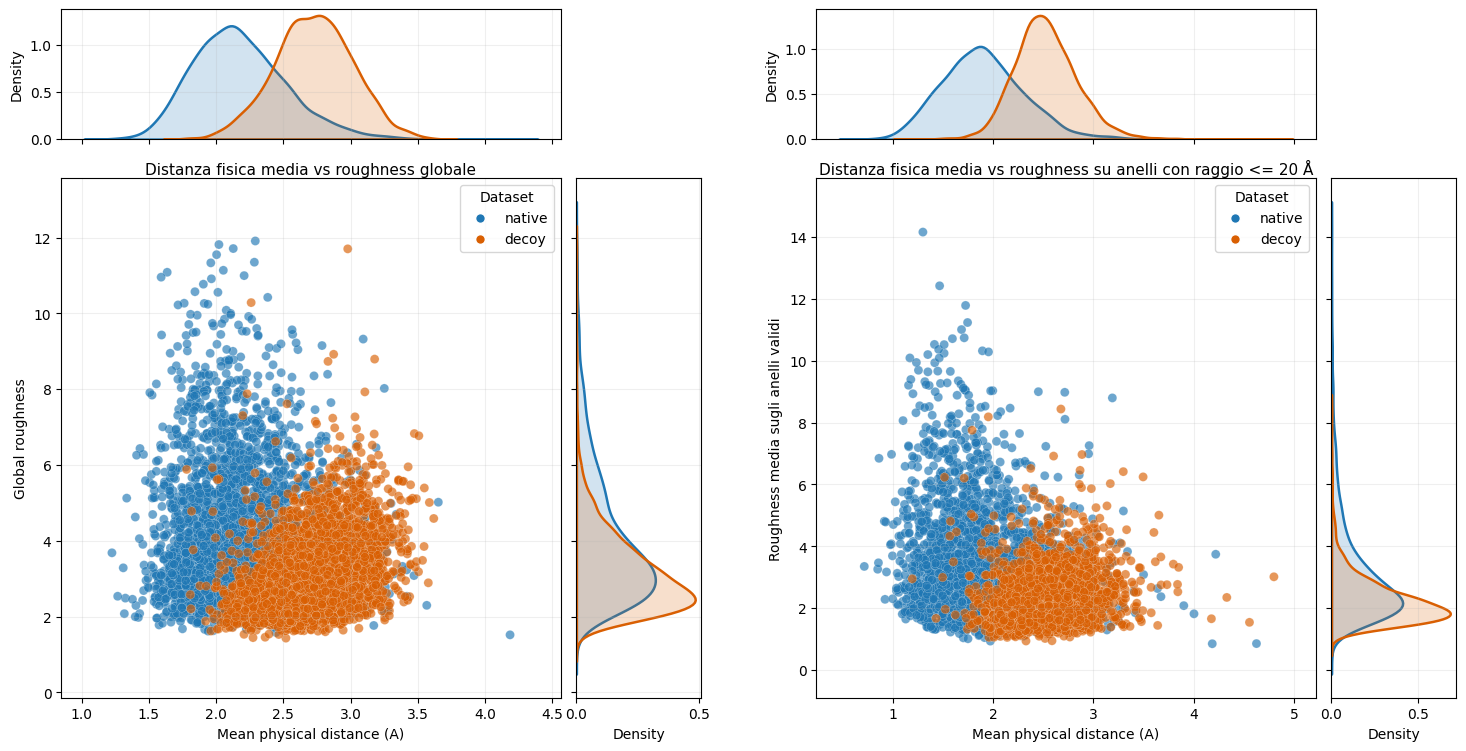

Punti global native: 3134
Punti global decoy: 3134
Punti filtrati native: 3123
Punti filtrati decoy: 3125
Separation global: AUC = 0.9123 +/- 0.004 | accuracy = 0.851 | n = 6268
Separation filtered: AUC = 0.903 +/- 0.0096 | accuracy = 0.8415 | n = 6248
Meglio separati: global
Physical mean global native: min / max = 1.2250244809207986 4.186349089671241
Physical mean global decoy: min / max = 1.7804382463298005 3.618791735978244
Physical mean filtered native: min / max = 0.7154839269135532 4.627309186836516
Physical mean filtered decoy: min / max = 1.1937064538488467 4.80123027771219


In [2]:
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

zernike_ring_cols = [f'zernike_ring{i}_mean' for i in range(1, 11)]
physical_ring_cols = [f'physical_ring{i}_mean' for i in range(1, 11)]
ring_mean_cols = [f'ring{i}_mean_A' for i in range(1, 11)]
roughness_ring_cols = [f'roughness_ring{i}' for i in range(1, 11)]


def summarize_by_complex(df, cols):
    grouped = df.groupby(['complex_name', 'dataset_label'], as_index=False)[cols].mean()
    wide_frames = []
    for dataset_label in ['native', 'decoy']:
        dataset_frame = grouped[grouped['dataset_label'] == dataset_label].set_index('complex_name')[cols]
        dataset_frame = dataset_frame.rename(columns={col: f'{col}_{dataset_label}' for col in cols})
        wide_frames.append(dataset_frame)
    return pd.concat(wide_frames, axis=1)


def build_plot_df(df, use_rdf_roughness=False, radius_limit=20.0):
    grouped_cols = ['radius', 'roughness'] + physical_ring_cols + roughness_ring_cols
    grouped = df.groupby(['complex_name', 'dataset_label'], as_index=False)[grouped_cols].mean()
    rows = []
    for dataset_label in ['native', 'decoy']:
        dataset_df = grouped[grouped['dataset_label'] == dataset_label]
        for _, row in dataset_df.iterrows():
            radius = pd.to_numeric(pd.Series([row['radius']]), errors='coerce').iloc[0]
            if not np.isfinite(radius) or radius <= 0:
                continue

            if use_rdf_roughness:
                valid_rings = [rid for rid in range(1, N_RINGS + 1) if radius * rid / float(N_RINGS) <= radius_limit]
                if not valid_rings:
                    continue
            else:
                valid_rings = list(range(1, N_RINGS + 1))

            physical_values = []
            for rid in valid_rings:
                physical_col = f'physical_ring{rid}_mean'
                if physical_col not in row.index:
                    continue
                physical_value = pd.to_numeric(pd.Series([row[physical_col]]), errors='coerce').iloc[0]
                if np.isfinite(physical_value):
                    physical_values.append(float(physical_value))

            if not physical_values:
                continue

            if use_rdf_roughness:
                roughness_values = []
                for rid in valid_rings:
                    roughness_col = f'roughness_ring{rid}'
                    if roughness_col not in row.index:
                        continue
                    roughness_value = pd.to_numeric(pd.Series([row[roughness_col]]), errors='coerce').iloc[0]
                    if np.isfinite(roughness_value):
                        roughness_values.append(float(roughness_value))

                if not roughness_values:
                    continue

                roughness_value = float(np.mean(roughness_values))
            else:
                roughness_value = pd.to_numeric(pd.Series([row['roughness']]), errors='coerce').iloc[0]
                if not np.isfinite(roughness_value):
                    continue
                roughness_value = float(roughness_value)

            rows.append({
                'complex_name': row['complex_name'],
                'dataset_label': dataset_label,
                'physical_mean': float(np.mean(physical_values)),
                'roughness': roughness_value,
            })

    return pd.DataFrame(rows)


def _safe_kde(ax, values, orientation, color):
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    if values.size < 2 or np.nanstd(values) == 0:
        if values.size == 1:
            if orientation == 'x':
                ax.axvline(values[0], color=color, linewidth=1.6, alpha=0.4)
            else:
                ax.axhline(values[0], color=color, linewidth=1.6, alpha=0.4)
        return
    if orientation == 'x':
        sns.kdeplot(x=values, ax=ax, color=color, linewidth=1.8, fill=True, alpha=0.20)
    else:
        sns.kdeplot(y=values, ax=ax, color=color, linewidth=1.8, fill=True, alpha=0.20)


def plot_joint_panel(fig, outer_spec, data, title, y_label):
    inner = outer_spec.subgridspec(2, 2, height_ratios=[1, 4], width_ratios=[4, 1], hspace=0.12, wspace=0.05)
    ax_marg_x = fig.add_subplot(inner[0, 0])
    ax_joint = fig.add_subplot(inner[1, 0], sharex=ax_marg_x)
    ax_marg_y = fig.add_subplot(inner[1, 1], sharey=ax_joint)
    ax_blank = fig.add_subplot(inner[0, 1])
    ax_blank.axis('off')

    sns.scatterplot(
        data=data,
        x='physical_mean',
        y='roughness',
        hue='dataset_label',
        hue_order=['native', 'decoy'],
        palette={'native': '#1f77b4', 'decoy': '#d95f02'},
        s=42,
        alpha=0.65,
        edgecolor='white',
        linewidth=0.2,
        ax=ax_joint,
        legend=False,
    )

    for dataset_label, color in [('native', '#1f77b4'), ('decoy', '#d95f02')]:
        subset = data.loc[data['dataset_label'] == dataset_label]
        _safe_kde(ax_marg_x, subset['physical_mean'], 'x', color)
        _safe_kde(ax_marg_y, subset['roughness'], 'y', color)

    ax_joint.set_title(title, fontsize=11, pad=3)
    ax_joint.set_xlabel('Mean physical distance (A)')
    ax_joint.set_ylabel(y_label)
    ax_joint.grid(alpha=0.2)

    ax_marg_x.set_ylabel('Density')
    ax_marg_y.set_xlabel('Density')
    ax_marg_x.grid(alpha=0.2)
    ax_marg_y.grid(alpha=0.2)
    ax_marg_x.tick_params(labelbottom=False)
    ax_marg_y.tick_params(labelleft=False)

    handles = [
        Line2D([0], [0], marker='o', linestyle='', markerfacecolor=color, markeredgecolor='white', markersize=7, label=label)
        for label, color in [('native', '#1f77b4'), ('decoy', '#d95f02')]
    ]
    ax_joint.legend(handles=handles, title='Dataset', loc='best')


def compare_separation(df, label):
    clean_df = df.dropna(subset=['physical_mean', 'roughness', 'dataset_label']).copy()
    if clean_df.empty or clean_df['dataset_label'].nunique() < 2:
        return {'label': label, 'n': int(clean_df.shape[0]), 'auc_mean': np.nan, 'auc_std': np.nan, 'accuracy_mean': np.nan}

    X = clean_df[['physical_mean', 'roughness']].to_numpy(dtype=float)
    y = (clean_df['dataset_label'] == 'decoy').astype(int).to_numpy()
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    return {
        'label': label,
        'n': int(clean_df.shape[0]),
        'auc_mean': float(np.mean(auc_scores)),
        'auc_std': float(np.std(auc_scores)),
        'accuracy_mean': float(np.mean(acc_scores)),
    }


plot_df_global = build_plot_df(tot_df, use_rdf_roughness=False)
plot_df_filtered = build_plot_df(tot_df, use_rdf_roughness=True, radius_limit=20.0)

separation_global = compare_separation(plot_df_global, 'global')
separation_filtered = compare_separation(plot_df_filtered, 'filtered')

fig = plt.figure(figsize=(18, 8.5))
outer = fig.add_gridspec(1, 2, wspace=0.18)

plot_joint_panel(
    fig,
    outer[0],
    plot_df_global,
    'Distanza fisica media vs roughness globale',
    'Global roughness',
)
plot_joint_panel(
    fig,
    outer[1],
    plot_df_filtered,
    'Distanza fisica media vs roughness su anelli con raggio <= 20 Å',
    'Roughness media sugli anelli validi',
)

fig.subplots_adjust(top=0.92)
plt.show()

print('Punti global native:', int((plot_df_global['dataset_label'] == 'native').sum()))
print('Punti global decoy:', int((plot_df_global['dataset_label'] == 'decoy').sum()))
print('Punti filtrati native:', int((plot_df_filtered['dataset_label'] == 'native').sum()))
print('Punti filtrati decoy:', int((plot_df_filtered['dataset_label'] == 'decoy').sum()))
print('Separation global: AUC =', round(separation_global['auc_mean'], 4), '+/-', round(separation_global['auc_std'], 4), '| accuracy =', round(separation_global['accuracy_mean'], 4), '| n =', separation_global['n'])
print('Separation filtered: AUC =', round(separation_filtered['auc_mean'], 4), '+/-', round(separation_filtered['auc_std'], 4), '| accuracy =', round(separation_filtered['accuracy_mean'], 4), '| n =', separation_filtered['n'])
print('Meglio separati:', 'filtered' if separation_filtered['auc_mean'] > separation_global['auc_mean'] else 'global')
print('Physical mean global native: min / max =', float(plot_df_global.loc[plot_df_global['dataset_label'] == 'native', 'physical_mean'].min()), float(plot_df_global.loc[plot_df_global['dataset_label'] == 'native', 'physical_mean'].max()))
print('Physical mean global decoy: min / max =', float(plot_df_global.loc[plot_df_global['dataset_label'] == 'decoy', 'physical_mean'].min()), float(plot_df_global.loc[plot_df_global['dataset_label'] == 'decoy', 'physical_mean'].max()))
print('Physical mean filtered native: min / max =', float(plot_df_filtered.loc[plot_df_filtered['dataset_label'] == 'native', 'physical_mean'].min()), float(plot_df_filtered.loc[plot_df_filtered['dataset_label'] == 'native', 'physical_mean'].max()))
print('Physical mean filtered decoy: min / max =', float(plot_df_filtered.loc[plot_df_filtered['dataset_label'] == 'decoy', 'physical_mean'].min()), float(plot_df_filtered.loc[plot_df_filtered['dataset_label'] == 'decoy', 'physical_mean'].max()))

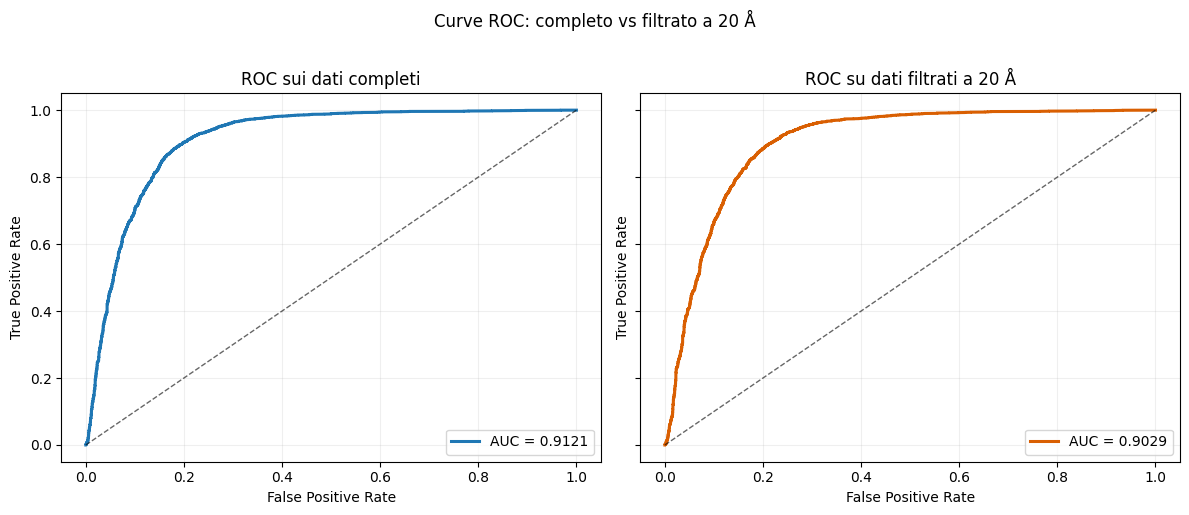

AUC ROC completo = 0.912110378014318
AUC ROC filtrato 20 Å = 0.9028937816202369


In [3]:
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_curves(ax, df, title, color):
    clean_df = df.dropna(subset=['physical_mean', 'roughness', 'dataset_label']).copy()
    if clean_df.empty or clean_df['dataset_label'].nunique() < 2:
        ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.grid(alpha=0.2)
        return np.nan

    X = clean_df[['physical_mean', 'roughness']].to_numpy(dtype=float)
    y = (clean_df['dataset_label'] == 'decoy').astype(int).to_numpy()
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    y_score = np.full_like(y, fill_value=np.nan, dtype=float)

    for train_idx, test_idx in cv.split(X, y):
        model.fit(X[train_idx], y[train_idx])
        y_score[test_idx] = model.predict_proba(X[test_idx])[:, 1]

    fpr, tpr, _ = roc_curve(y, y_score)
    auc_value = roc_auc_score(y, y_score)
    ax.plot(fpr, tpr, color=color, linewidth=2.2, label=f'AUC = {auc_value:.4f}')
    ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.grid(alpha=0.2)
    ax.legend(loc='lower right')
    return auc_value

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
auc_global_roc = plot_roc_curves(axes[0], plot_df_global, 'ROC sui dati completi', '#1f77b4')
auc_filtered_roc = plot_roc_curves(axes[1], plot_df_filtered, 'ROC su dati filtrati a 20 Å', '#d95f02')
fig.suptitle('Curve ROC: completo vs filtrato a 20 Å', y=1.02)
plt.tight_layout()
plt.show()

print('AUC ROC completo =', float(auc_global_roc))
print('AUC ROC filtrato 20 Å =', float(auc_filtered_roc))

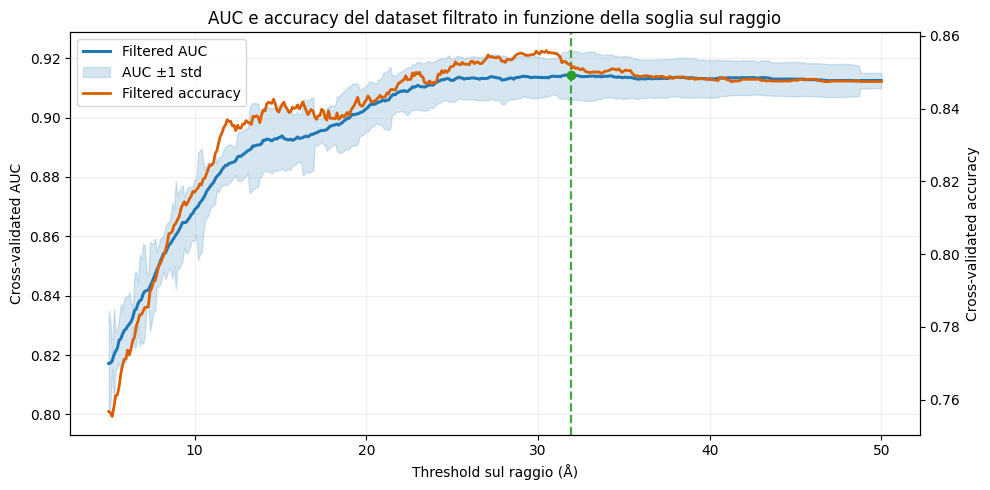

Soglia migliore: 31.899999999999906
AUC migliore: 0.914395970970409
Accuracy alla soglia migliore: 0.8521407793892681
Numero di punti alla soglia migliore: 6256
Ultima soglia testata: 49.999999999999844
AUC allultima soglia: 0.9124957443404412
Accuracy allultima soglia: 0.8474440894568691


In [7]:
threshold_step = 0.1
max_threshold = 50
thresholds = np.arange(5.0, max_threshold + 1e-9, threshold_step)

threshold_base_df = tot_df.groupby(['complex_name', 'dataset_label'], as_index=False)[['radius'] + physical_ring_cols + roughness_ring_cols].mean()

def build_threshold_plot_df(grouped_df, radius_limit):
    radius = grouped_df['radius'].to_numpy(dtype=float)
    ring_ids = np.arange(1, N_RINGS + 1, dtype=float)
    valid_mask = (ring_ids[None, :] * radius[:, None] / float(N_RINGS)) <= float(radius_limit)

    physical_values = grouped_df[physical_ring_cols].to_numpy(dtype=float)
    roughness_values = grouped_df[roughness_ring_cols].to_numpy(dtype=float)

    physical_masked = np.where(valid_mask, physical_values, np.nan)
    roughness_masked = np.where(valid_mask, roughness_values, np.nan)

    physical_count = np.sum(np.isfinite(physical_masked), axis=1)
    roughness_count = np.sum(np.isfinite(roughness_masked), axis=1)
    physical_sum = np.nansum(physical_masked, axis=1)
    roughness_sum = np.nansum(roughness_masked, axis=1)

    physical_mean = np.divide(
        physical_sum,
        physical_count,
        out=np.full(physical_sum.shape, np.nan, dtype=float),
        where=physical_count > 0,
    )
    roughness_mean = np.divide(
        roughness_sum,
        roughness_count,
        out=np.full(roughness_sum.shape, np.nan, dtype=float),
        where=roughness_count > 0,
    )

    result = grouped_df[['complex_name', 'dataset_label']].copy()
    result['radius'] = radius
    result['physical_mean'] = physical_mean
    result['roughness'] = roughness_mean
    return result.dropna(subset=['physical_mean', 'roughness']).copy()


auc_threshold_rows = []
for threshold in thresholds:
    filtered_df = build_threshold_plot_df(threshold_base_df, float(threshold))
    separation = compare_separation(filtered_df, f'filtered_{threshold:.1f}')
    auc_threshold_rows.append({
        'threshold_A': float(threshold),
        'auc_mean': separation['auc_mean'],
        'auc_std': separation['auc_std'],
        'accuracy_mean': separation['accuracy_mean'],
        'n': separation['n'],
    })

auc_threshold_df = pd.DataFrame(auc_threshold_rows)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(auc_threshold_df['threshold_A'], auc_threshold_df['auc_mean'], color='#1f77b4', linewidth=2.2, label='Filtered AUC')
ax1.fill_between(
    auc_threshold_df['threshold_A'],
    auc_threshold_df['auc_mean'] - auc_threshold_df['auc_std'],
    auc_threshold_df['auc_mean'] + auc_threshold_df['auc_std'],
    color='#1f77b4',
    alpha=0.18,
    label='AUC ±1 std',
)
ax2 = ax1.twinx()
ax2.plot(auc_threshold_df['threshold_A'], auc_threshold_df['accuracy_mean'], color='#d95f02', linewidth=2.0, label='Filtered accuracy')
ax2.set_ylabel('Cross-validated accuracy')
best_idx = auc_threshold_df['auc_mean'].idxmax()
best_row = auc_threshold_df.loc[best_idx]
ax1.axvline(best_row['threshold_A'], color='#2ca02c', linestyle='--', linewidth=1.6, alpha=0.9)
ax1.scatter([best_row['threshold_A']], [best_row['auc_mean']], color='#2ca02c', zorder=3)
ax1.set_title('AUC e accuracy del dataset filtrato in funzione della soglia sul raggio')
ax1.set_xlabel('Threshold sul raggio (Å)')
ax1.set_ylabel('Cross-validated AUC')
ax1.grid(alpha=0.2)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
fig.tight_layout()
plt.show()

print('Soglia migliore:', float(best_row['threshold_A']))
print('AUC migliore:', float(best_row['auc_mean']))
print('Accuracy alla soglia migliore:', float(best_row['accuracy_mean']))
print('Numero di punti alla soglia migliore:', int(best_row['n']))
print('Ultima soglia testata:', float(auc_threshold_df['threshold_A'].iloc[-1]))
print('AUC all' + 'ultima soglia:', float(auc_threshold_df['auc_mean'].iloc[-1]))
print('Accuracy all' + 'ultima soglia:', float(auc_threshold_df['accuracy_mean'].iloc[-1]))

/home/giovanni/.cache/pypoetry/virtualenvs/zernike2d-UypCNOlF-py3.12/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_86920/3905959999.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


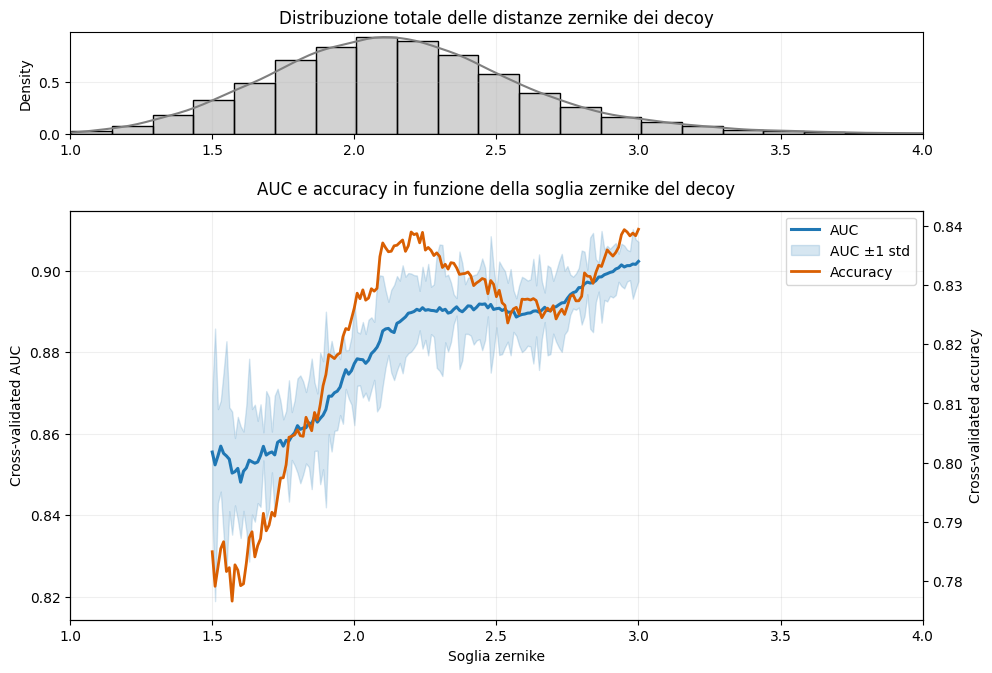

Soglia zernike migliore: 3.0000000000000013
AUC migliore: 0.9022853868149541
Accuracy alla soglia migliore: 0.8393911244975074
Numero di punti alla soglia migliore: 6108
Ultima soglia testata: 3.0000000000000013
AUC allultima soglia: 0.9022853868149541
Accuracy allultima soglia: 0.8393911244975074


In [13]:
zernike_threshold_step = 0.01
zernike_thresholds = np.arange(1.5, 3.0 + 1e-9, zernike_threshold_step)

zernike_threshold_base_df = tot_df.groupby(['complex_name', 'dataset_label'], as_index=False)[['radius'] + zernike_ring_cols + physical_ring_cols + roughness_ring_cols].mean()
all_decoy_zernike_values = pd.to_numeric(decoys_df[zernike_ring_cols].stack(), errors='coerce').dropna().to_numpy(dtype=float)

def build_zernike_threshold_plot_df(grouped_df, zernike_limit):
    decoy_df = grouped_df[grouped_df['dataset_label'] == 'decoy'].copy()
    cutoff_map = {}
    for _, row in decoy_df.iterrows():
        zernike_values = row[zernike_ring_cols].to_numpy(dtype=float)
        valid_mask = np.isfinite(zernike_values)
        above_limit = np.where(valid_mask & (zernike_values > float(zernike_limit)))[0]
        if above_limit.size > 0:
            cutoff_map[row['complex_name']] = int(above_limit[0]) + 1
        else:
            cutoff_map[row['complex_name']] = N_RINGS + 1

    rows = []
    for _, row in grouped_df.iterrows():
        cutoff_ring = cutoff_map.get(row['complex_name'], N_RINGS + 1)
        selected_rings = list(range(1, cutoff_ring))
        if not selected_rings:
            continue

        physical_values = []
        roughness_values = []
        for rid in selected_rings:
            physical_value = pd.to_numeric(pd.Series([row[f'physical_ring{rid}_mean']]), errors='coerce').iloc[0]
            roughness_value = pd.to_numeric(pd.Series([row[f'roughness_ring{rid}']]), errors='coerce').iloc[0]
            if np.isfinite(physical_value):
                physical_values.append(float(physical_value))
            if np.isfinite(roughness_value):
                roughness_values.append(float(roughness_value))

        if not physical_values or not roughness_values:
            continue

        rows.append({
            'complex_name': row['complex_name'],
            'dataset_label': row['dataset_label'],
            'physical_mean': float(np.mean(physical_values)),
            'roughness': float(np.mean(roughness_values)),
        })

    return pd.DataFrame(rows)


zernike_auc_rows = []
for threshold in zernike_thresholds:
    filtered_df = build_zernike_threshold_plot_df(zernike_threshold_base_df, float(threshold))
    separation = compare_separation(filtered_df, f'zernike_filtered_{threshold:.1f}')
    zernike_auc_rows.append({
        'threshold_zernike': float(threshold),
        'auc_mean': separation['auc_mean'],
        'auc_std': separation['auc_std'],
        'accuracy_mean': separation['accuracy_mean'],
        'n': separation['n'],
    })

zernike_auc_df = pd.DataFrame(zernike_auc_rows)

fig = plt.figure(figsize=(11, 7))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 4], hspace=0.30)
ax_top = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0])

sns.histplot(all_decoy_zernike_values, bins=40, stat='density', kde=True, color='#7f7f7f', alpha=0.35, ax=ax_top)
ax_top.set_ylabel('Density')
ax_top.set_xlabel('')
ax_top.set_title('Distribuzione totale delle distanze zernike dei decoy')
ax_top.set_xlim(1, 4)
ax_top.grid(alpha=0.2)

ax1.plot(zernike_auc_df['threshold_zernike'], zernike_auc_df['auc_mean'], color='#1f77b4', linewidth=2.2, label='AUC')
ax1.fill_between(
    zernike_auc_df['threshold_zernike'],
    zernike_auc_df['auc_mean'] - zernike_auc_df['auc_std'],
    zernike_auc_df['auc_mean'] + zernike_auc_df['auc_std'],
    color='#1f77b4',
    alpha=0.18,
    label='AUC ±1 std',
)
ax2 = ax1.twinx()
ax2.plot(zernike_auc_df['threshold_zernike'], zernike_auc_df['accuracy_mean'], color='#d95f02', linewidth=2.0, label='Accuracy')
ax2.set_ylabel('Cross-validated accuracy')
best_idx = zernike_auc_df['auc_mean'].idxmax()
best_row = zernike_auc_df.loc[best_idx]
ax1.set_title('AUC e accuracy in funzione della soglia zernike del decoy', pad=12)
ax1.set_xlabel('Soglia zernike')
ax1.set_ylabel('Cross-validated AUC')
ax1.set_xlim(1, 4)
ax1.grid(alpha=0.2)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
fig.tight_layout()
fig.subplots_adjust(top=0.95)
plt.show()

print('Soglia zernike migliore:', float(best_row['threshold_zernike']))
print('AUC migliore:', float(best_row['auc_mean']))
print('Accuracy alla soglia migliore:', float(best_row['accuracy_mean']))
print('Numero di punti alla soglia migliore:', int(best_row['n']))
print('Ultima soglia testata:', float(zernike_auc_df['threshold_zernike'].iloc[-1]))
print('AUC all' + 'ultima soglia:', float(zernike_auc_df['auc_mean'].iloc[-1]))
print('Accuracy all' + 'ultima soglia:', float(zernike_auc_df['accuracy_mean'].iloc[-1]))

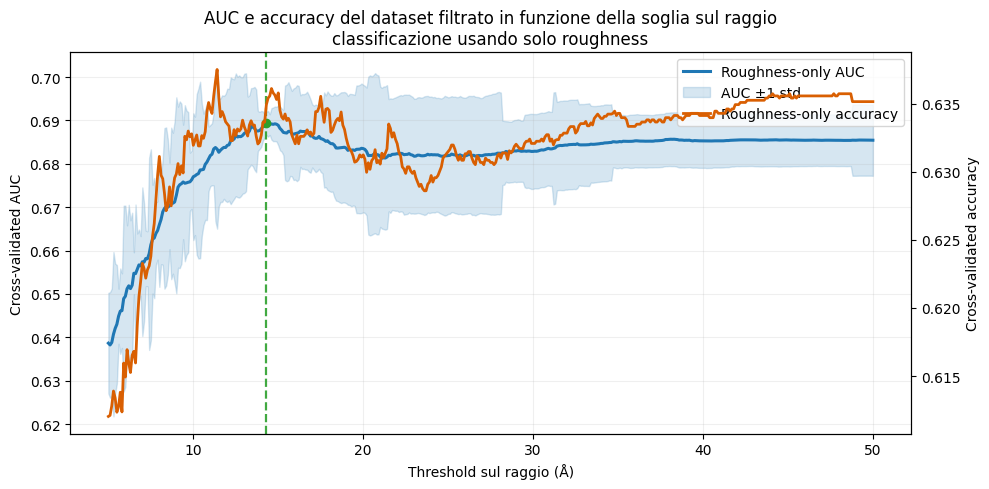

Soglia migliore: 14.299999999999967
AUC migliore: 0.689329398995919
Accuracy alla soglia migliore: 0.6349224035120187
Numero di punti alla soglia migliore: 6237
Ultima soglia testata: 49.999999999999844
AUC allultima soglia: 0.685430436106282
Accuracy allultima soglia: 0.6351437699680511


In [4]:
roughness_auc_rows = []
for threshold in thresholds:
    filtered_df = build_threshold_plot_df(threshold_base_df, float(threshold))
    separation = compare_separation(filtered_df, f'roughness_filtered_{threshold:.1f}', feature_cols=('roughness',))
    roughness_auc_rows.append({
        'threshold_A': float(threshold),
        'auc_mean': separation['auc_mean'],
        'auc_std': separation['auc_std'],
        'accuracy_mean': separation['accuracy_mean'],
        'n': separation['n'],
    })

roughness_auc_df = pd.DataFrame(roughness_auc_rows)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(roughness_auc_df['threshold_A'], roughness_auc_df['auc_mean'], color='#1f77b4', linewidth=2.2, label='Roughness-only AUC')
ax1.fill_between(
    roughness_auc_df['threshold_A'],
    roughness_auc_df['auc_mean'] - roughness_auc_df['auc_std'],
    roughness_auc_df['auc_mean'] + roughness_auc_df['auc_std'],
    color='#1f77b4',
    alpha=0.18,
    label='AUC ±1 std',
)
ax2 = ax1.twinx()
ax2.plot(roughness_auc_df['threshold_A'], roughness_auc_df['accuracy_mean'], color='#d95f02', linewidth=2.0, label='Roughness-only accuracy')
ax2.set_ylabel('Cross-validated accuracy')
best_idx = roughness_auc_df['auc_mean'].idxmax()
best_row = roughness_auc_df.loc[best_idx]
ax1.axvline(best_row['threshold_A'], color='#2ca02c', linestyle='--', linewidth=1.6, alpha=0.9)
ax1.scatter([best_row['threshold_A']], [best_row['auc_mean']], color='#2ca02c', zorder=3)
ax1.set_title('AUC e accuracy del dataset filtrato in funzione della soglia sul raggio\nclassificazione usando solo roughness')
ax1.set_xlabel('Threshold sul raggio (Å)')
ax1.set_ylabel('Cross-validated AUC')
ax1.grid(alpha=0.2)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
fig.tight_layout()
plt.show()

print('Soglia migliore:', float(best_row['threshold_A']))
print('AUC migliore:', float(best_row['auc_mean']))
print('Accuracy alla soglia migliore:', float(best_row['accuracy_mean']))
print('Numero di punti alla soglia migliore:', int(best_row['n']))
print('Ultima soglia testata:', float(roughness_auc_df['threshold_A'].iloc[-1]))
print('AUC all' + 'ultima soglia:', float(roughness_auc_df['auc_mean'].iloc[-1]))
print('Accuracy all' + 'ultima soglia:', float(roughness_auc_df['accuracy_mean'].iloc[-1]))

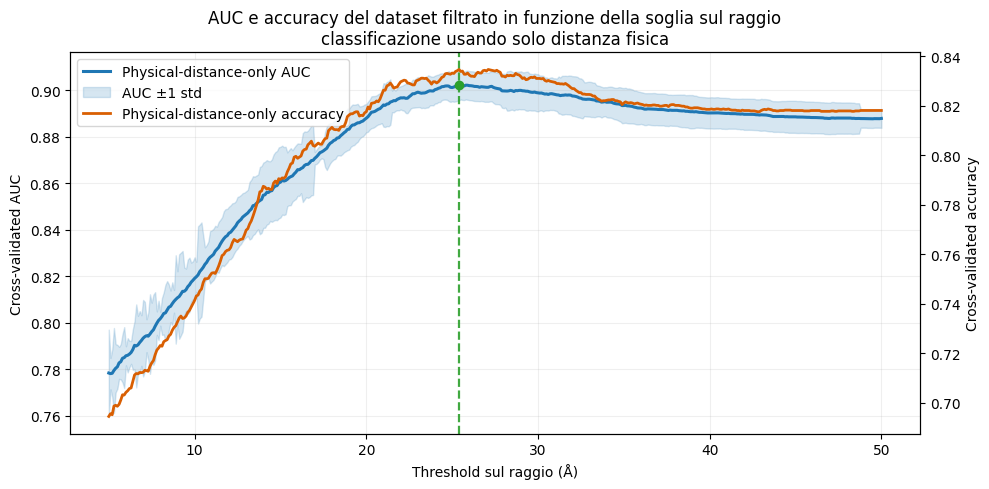

Soglia migliore: 25.399999999999928
AUC migliore: 0.902374918746293
Accuracy alla soglia migliore: 0.8346149960031974
Numero di punti alla soglia migliore: 6252
Ultima soglia testata: 49.999999999999844
AUC allultima soglia: 0.8879359192042049
Accuracy allultima soglia: 0.8180511182108627


In [5]:
physical_auc_rows = []
for threshold in thresholds:
    filtered_df = build_threshold_plot_df(threshold_base_df, float(threshold))
    separation = compare_separation(filtered_df, f'physical_filtered_{threshold:.1f}', feature_cols=('physical_mean',))
    physical_auc_rows.append({
        'threshold_A': float(threshold),
        'auc_mean': separation['auc_mean'],
        'auc_std': separation['auc_std'],
        'accuracy_mean': separation['accuracy_mean'],
        'n': separation['n'],
    })

physical_auc_df = pd.DataFrame(physical_auc_rows)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(physical_auc_df['threshold_A'], physical_auc_df['auc_mean'], color='#1f77b4', linewidth=2.2, label='Physical-distance-only AUC')
ax1.fill_between(
    physical_auc_df['threshold_A'],
    physical_auc_df['auc_mean'] - physical_auc_df['auc_std'],
    physical_auc_df['auc_mean'] + physical_auc_df['auc_std'],
    color='#1f77b4',
    alpha=0.18,
    label='AUC ±1 std',
)
ax2 = ax1.twinx()
ax2.plot(physical_auc_df['threshold_A'], physical_auc_df['accuracy_mean'], color='#d95f02', linewidth=2.0, label='Physical-distance-only accuracy')
ax2.set_ylabel('Cross-validated accuracy')
best_idx = physical_auc_df['auc_mean'].idxmax()
best_row = physical_auc_df.loc[best_idx]
ax1.axvline(best_row['threshold_A'], color='#2ca02c', linestyle='--', linewidth=1.6, alpha=0.9)
ax1.scatter([best_row['threshold_A']], [best_row['auc_mean']], color='#2ca02c', zorder=3)
ax1.set_title('AUC e accuracy del dataset filtrato in funzione della soglia sul raggio\nclassificazione usando solo distanza fisica')
ax1.set_xlabel('Threshold sul raggio (Å)')
ax1.set_ylabel('Cross-validated AUC')
ax1.grid(alpha=0.2)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
fig.tight_layout()
plt.show()

print('Soglia migliore:', float(best_row['threshold_A']))
print('AUC migliore:', float(best_row['auc_mean']))
print('Accuracy alla soglia migliore:', float(best_row['accuracy_mean']))
print('Numero di punti alla soglia migliore:', int(best_row['n']))
print('Ultima soglia testata:', float(physical_auc_df['threshold_A'].iloc[-1]))
print('AUC all' + 'ultima soglia:', float(physical_auc_df['auc_mean'].iloc[-1]))
print('Accuracy all' + 'ultima soglia:', float(physical_auc_df['accuracy_mean'].iloc[-1]))